# W&B Sweep — DQN
Búsqueda de hiperparámetros para el agente DQN en el ambiente Simple (CSTR).
- Método: Random Search
- Proyecto W&B: `Tesis_DQN`
- Arquitectura: Simple (CTRL únicamente)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1451, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1451 (delta 3), reused 8 (delta 2), pack-reused 1440 (from 1)
Receiving objects: 100% (1451/1451), 32.13 MiB | 47.97 MiB/s, done.
Resolving deltas: 100% (867/867), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Agente.DQN.train_DQN import DQNTrainer
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cu128
Device: CUDA


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Mar  7 23:26:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Login W&B

In [5]:
!pip install wandb --quiet

In [6]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [7]:
# ============ CONFIG RUN PRINCIPAL POST-FIX ============

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN_CTRL'
RUN_NAME      = 'dqn_re_entrnenado_15k'

N_EPISODES               = 15000
EVAL_FREQUENCY           = 100
LOG_FREQUENCY            = 100
SAVE_FREQUENCY           = 2000
EARLY_STOPPING_PATIENCE  = 50
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
SEED                     = 42

trainer_config = {
    'env_config': {
        'architecture'        : 'simple',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : [(300, 420), (90, 115)],
        'manipulable_setpoints': None,
        'dt_usuario'          : 1.0,
        'max_steps'           : 20,
        'max_time_detector'   : 15,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'reward_weights'      : {'error': 3.0, 'tiempo': 0.1, 'overshoot': 0.1, 'energy': 0.05},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_controller_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (90, 115))},
        'stability_config'    : {
            'error_increase_tolerance': 1.2,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },
    'agent_ctrl_config': {
        'state_dim'         : 10,
        'action_dim'        : 7,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-05,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 128,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 50000,
        'device'            : 'cuda' if torch.cuda.is_available() else 'cpu',
        'seed'              : SEED,
    },
    'n_episodes'     : N_EPISODES,
    'eval_frequency' : EVAL_FREQUENCY,
    'log_frequency'  : LOG_FREQUENCY,
    'save_frequency' : SAVE_FREQUENCY,
    'checkpoint_dir' : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'     : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# ============ REPRODUCIBILIDAD ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ============ INIT WANDB ============
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['post-fix', 'clamp', '15k', 'produccion'],  # fácil de filtrar en W&B
    config  = trainer_config,
)

# ============ ENTRENAR ============
cstr    = CSTRSimulator(dt=1.0, control_limits=((300, 420), (90, 115)))
trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

# ============ GUARDAR PESOS EN W&B ============
import os
checkpoint_path = f'checkpoints/{RUN_NAME}'
if os.path.exists(checkpoint_path):
    artifact = wandb.Artifact(
        name = f'model_{RUN_NAME}',
        type = 'model',
        description = 'Pesos DQN post-fix clamp, 15k episodios'
    )
    artifact.add_dir(checkpoint_path)
    wandb.log_artifact(artifact)

# ============ MÉTRICAS FINALES ============
wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
})

wandb.finish()
print(f'Run completado: {RUN_NAME}')


Episodio 0/15000
  Reward: -2.45
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 100/15000
  Reward: -0.26
  Length: 20
  CTRL Loss: 178.2938
  CTRL Epsilon: 0.3880
Evaluación: Reward promedio = -0.54
Agente guardado en: checkpoints/dqn_re_entrnenado_15k/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -1.01
  Length: 20
  CTRL Loss: 55.9674
  CTRL Epsilon: 0.1427
Evaluación: Reward promedio = -1.36
  Sin mejora: 1/50

Episodio 300/15000
  Reward: -0.43
  Length: 20
  CTRL Loss: 33.6408
  CTRL Epsilon: 0.0525
Evaluación: Reward promedio = -3.08
  Sin mejora: 2/50

Episodio 400/15000
  Reward: -0.87
  Length: 20
  CTRL Loss: 25.3527
  CTRL Epsilon: 0.0193
Evaluación: Reward promedio = -1.21
  Sin mejora: 3/50

Episodio 500/15000
  Reward: -0.75
  Length: 20
  CTRL Loss: 14.2627
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -0.63
  Sin mejora: 4/50

Episodio 600/15000
  Reward: -0.57
  Length: 20
  CTRL Loss: 11.8995
  CTRL Epsilon: 0.0

wandb: Adding directory to artifact (checkpoints/dqn_re_entrnenado_15k)... Done. 0.0s


Evaluación: Reward promedio = -0.44
  Sin mejora: 50/50
Early stopping en episodio 10000


energy,▁▂█▁▂▅▆▁▂▁▂▁▁▅▂▁▂▆▁▃▂▂▂▂▁▄▁▁▁▃▁▂▁▁▂▁▆▁▂▁
epsilon,█▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▁▂▆▄▇▇▆▇▅▄▆▅▆▆█▆▄▆▄▇▇▆▇▅█▄█▇██▆▇▇▆▇▇▇██▇
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁█
kd_var1,▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁
+8,...


Run completado: dqn_re_entrnenado_15k


Analisis de resultados

In [12]:
api = wandb.Api()
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN_CTRL/vo0ba1tj')
hist = list(r.scan_history())
df_post = pd.DataFrame(hist)
print(df_post.columns.tolist())

['epsilon', '_timestamp', 'kp_var0', '_step', 'kd_var1', 'ki_var0', 'overshoot', 'reward', 'energy', 'kd_var0', 'ki_var1', 'loss', '_runtime', 'kp_var1', 'eval_reward', 'final_energy_mean10', 'final_overshoot_mean10', 'final_reward_mean10', 'final_eval_reward', 'total_episodes', 'final_epsilon']


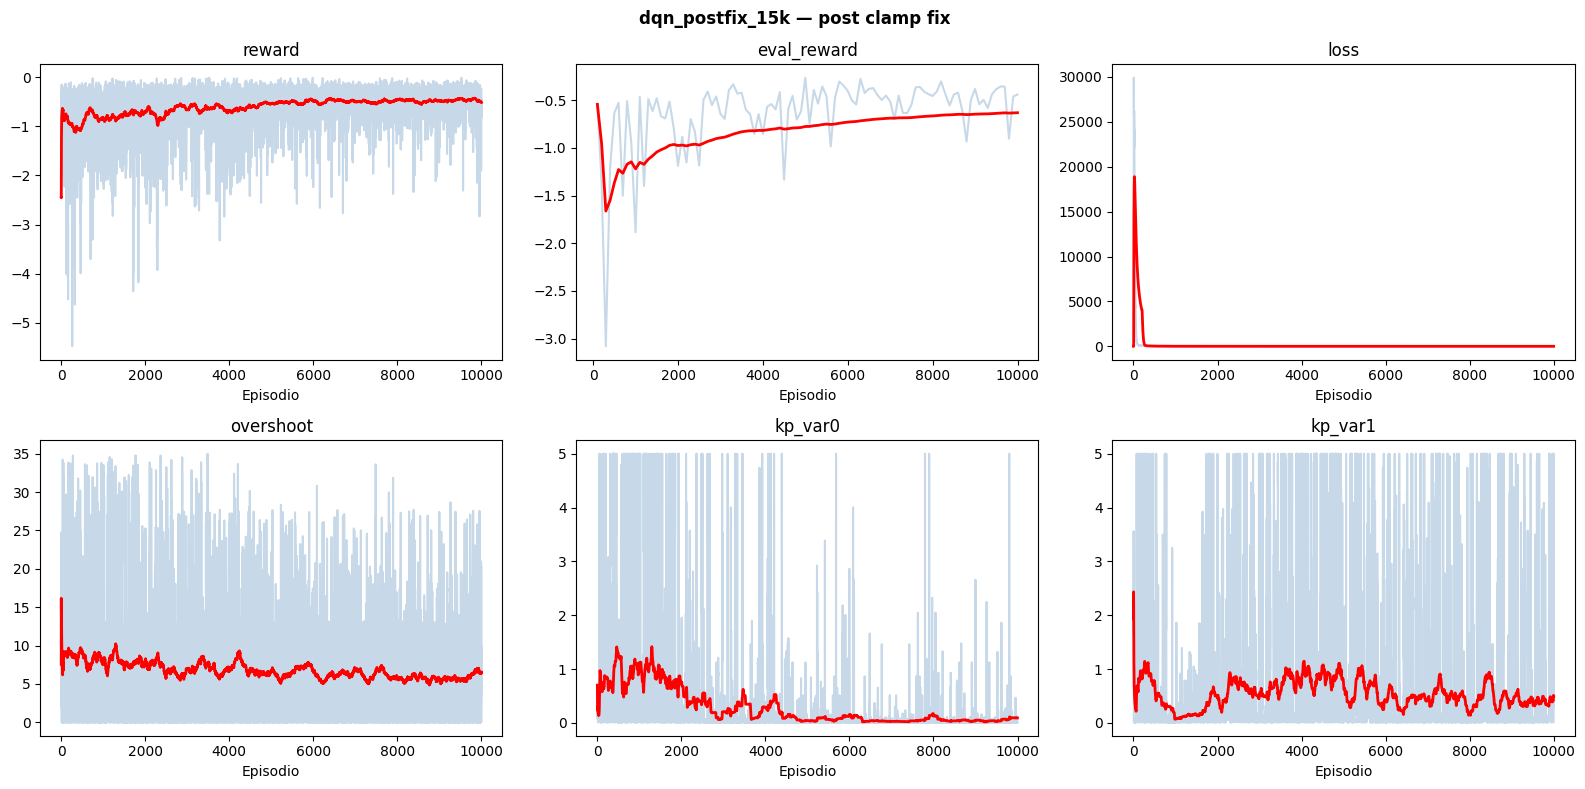

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot', 'kp_var0', 'kp_var1']

for ax, col in zip(axes.flat, metricas):
    d = df_post[['_step', col]].dropna()
    ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
    ax.plot(d['_step'], d[col].rolling(200, min_periods=1).mean(), color='red', lw=2)
    ax.set_title(col)
    ax.set_xlabel('Episodio')

plt.suptitle('dqn_postfix_15k — post clamp fix', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from Agente.DQN.algorithm_DQN import DQNAgent
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

In [16]:
agent = DQNAgent(
    state_dim=10,
    action_dim=7,
    n_vars=2,
    agent_role='ctrl',
    hidden_dims=(128, 64),
    device='cpu',
    seed=42
)
agent.load('/content/checkpoints/dqn_re_entrnenado_15k/agent_ctrl_best.pt')
agent.epsilon = 0.0  # sin exploración, pura explotación
print('Agente cargado')

Agente cargado


Prueba de funcionamiento del agente

In [21]:
cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (90, 115)))
cstr.reset()

pid_controllers = [
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(300, 420)),
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(90, 115))
]
apply_action = ApplyAction(
    delta_percent_ctrl=0.3,
    pid_limits=[(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
    manipulable_ranges=[(300, 420), (90, 115)]
)

T_sp, V_sp = 340.0, 100.0
sps = [T_sp, V_sp]
pvs = [cstr.T_ss, cstr.V_ss]

# Acumular errores entre steps
error_integral = [0.0, 0.0]
error_prev     = [sps[i] - pvs[i] for i in range(2)]

traj_T, traj_V = [pvs[0]], [pvs[1]]
traj_kp0, traj_kp1 = [], []

detector = ResponseTimeDetector(proceso=cstr, env_type='simulation', dt=1.0, tolerance=0.02)
for step in range(20):
    errors = [sps[i] - pvs[i] for i in range(2)]

    # Acumular integral y derivada
    for i in range(2):
        error_integral[i] += errors[i] * 1.0
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent.select_action(state, training=False)
    print(f'Step {step+1:2d} | action={action}', end='')

    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='discrete',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    traj_kp0.append(pid_controllers[0].kp)
    traj_kp1.append(pid_controllers[1].kp)


    resultado = detector.estimate(pvs_inicial=pvs, sps=sps, pid_controllers=pid_controllers, max_time=15, reset_pid=False)

    pvs = resultado['pvs_final']
    traj_T.append(pvs[0])
    traj_V.append(pvs[1])
    print(f' | T={pvs[0]:.2f} | V={pvs[1]:.3f} | kp0={pid_controllers[0].kp:.4f} | kp1={pid_controllers[1].kp:.4f}')

Step  1 | action=[6 6] | T=332.61 | V=98.156 | kp0=1.0000 | kp1=1.0000
Step  2 | action=[4 3] | T=329.05 | V=99.755 | kp0=1.0000 | kp1=0.7000
Step  3 | action=[1 3] | T=356.92 | V=100.012 | kp0=1.0000 | kp1=0.4900
Step  4 | action=[0 1] | T=346.69 | V=99.597 | kp0=1.3000 | kp1=0.4900
Step  5 | action=[6 6] | T=346.02 | V=100.001 | kp0=1.3000 | kp1=0.4900
Step  6 | action=[6 6] | T=342.17 | V=100.010 | kp0=1.3000 | kp1=0.4900
Step  7 | action=[6 6] | T=342.17 | V=100.008 | kp0=1.3000 | kp1=0.4900
Step  8 | action=[4 6] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.4900
Step  9 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.3430
Step 10 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.2401
Step 11 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.1681
Step 12 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.1176
Step 13 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.0824
Step 14 | action=[4 3] | T=339.62 | V=99.997 | kp0=1.3000 | kp1=0.0576
St

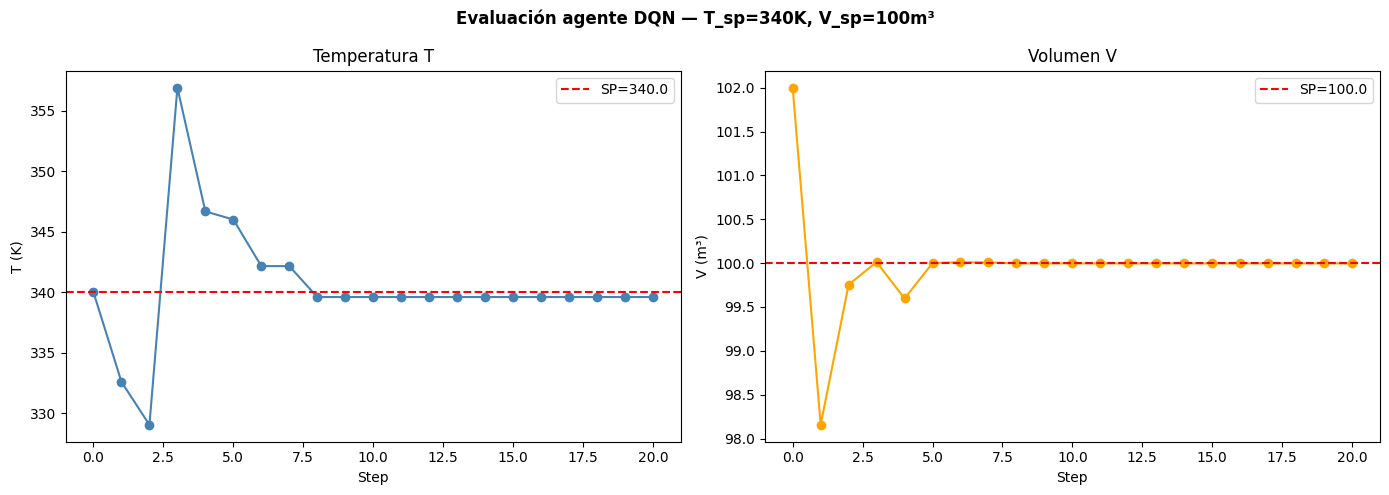

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_T, marker='o', color='steelblue')
axes[0].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp}')
axes[0].set_title('Temperatura T')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('T (K)')
axes[0].legend()

axes[1].plot(traj_V, marker='o', color='orange')
axes[1].axhline(V_sp, color='red', linestyle='--', label=f'SP={V_sp}')
axes[1].set_title('Volumen V')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('V (m³)')
axes[1].legend()

plt.suptitle('Evaluación agente DQN — T_sp=340K, V_sp=100m³', fontweight='bold')
plt.tight_layout()
plt.show()

El agente aprendio muy bien! llega rapido y sin overshots! Paso al entrenamiento del orch.